## AR to ARIMA

We will begin with univariate analysis.


In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns']]
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


We have to ensure this is a stationary data (no trend)

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(fin_data['weighted_sector_returns'])
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-13.191191464558408), np.float64(1.143191313494307e-24), 8, 2254, {'1%': np.float64(-3.43325450880204), '5%': np.float64(-2.862823135013053), '10%': np.float64(-2.567453072861103)}, np.float64(8389.703138052395))
stationary


In [4]:
fin_data['weighted_sector_returns'].describe()

count    2263.000000
mean        0.160621
std         1.605039
min       -13.106859
25%        -0.510407
50%         0.058116
75%         0.767203
max         9.392698
Name: weighted_sector_returns, dtype: float64

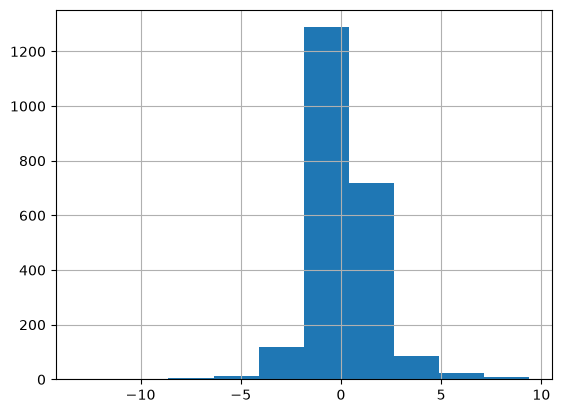

In [5]:
import matplotlib.pyplot as plt
ax=fin_data['weighted_sector_returns'].hist()

plt.show()

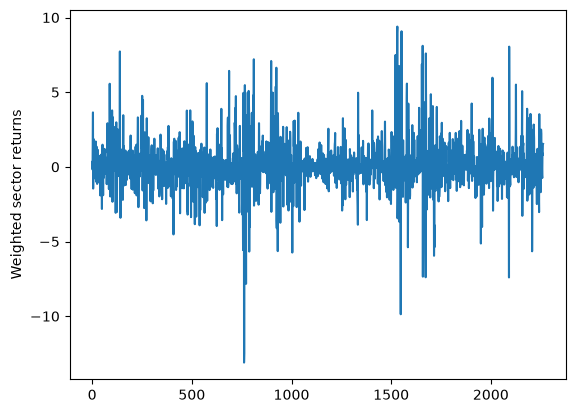

In [6]:
import matplotlib.pyplot as plt
ax=fin_data['weighted_sector_returns'].plot()
ax.set_ylabel('Weighted sector returns')
plt.show()

In [7]:
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     2263 non-null   str    
 1   weighted_sector_returns  2263 non-null   float64
dtypes: float64(1), str(1)
memory usage: 35.5 KB


In [8]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


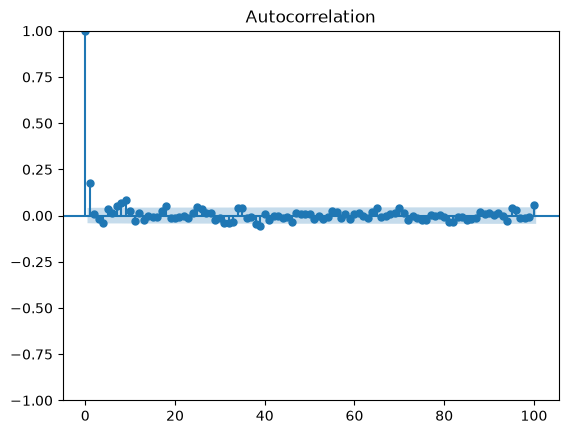

In [9]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(fin_data['weighted_sector_returns'], lags=100) ## acf is short for autocorrelation function
plt.show()

Lags with 1, 8, 9, 18, 39, 100 have significant autocorrelation

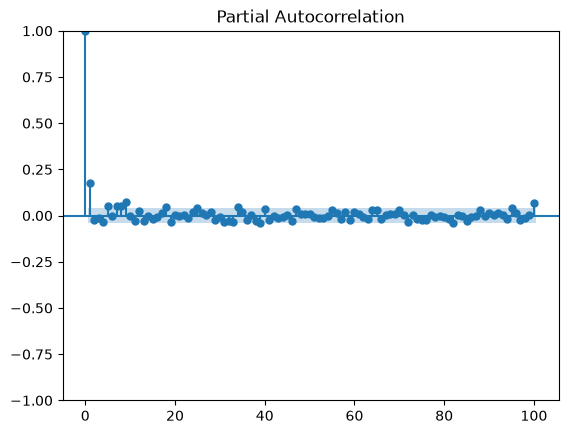

In [10]:
## partial autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(fin_data['weighted_sector_returns'], lags = 100)
plt.show()

In [11]:
# Estimate Yule-Walker AR coefficients with order 20
from statsmodels.regression.linear_model import yule_walker

coefficients, sigma = yule_walker(fin_data['weighted_sector_returns'], order = 20)

print('coefficients: ', -coefficients)
print('sigma: ', sigma)

coefficients:  [-0.17604882  0.02637502  0.00597369  0.04328665 -0.05497302  0.0084761
 -0.04276545 -0.04203294 -0.06590152 -0.00611985  0.03641016 -0.03158318
  0.03122695 -0.00719265  0.0187755   0.0100623  -0.00579487 -0.05113925
  0.03352949 -0.00174884]
sigma:  1.5634230396878819


In [12]:
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


In [13]:
from sklearn.metrics import r2_score

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate(order):
    train = list(fin_data['weighted_sector_returns'])[:-10]
    test = list(fin_data['weighted_sector_returns'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(fin_data['weighted_sector_returns']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [14]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
17,18,-0.101337


The performance is worse than guessing. We will try to use monthly data

In [15]:
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


In [16]:
finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


To do the monthly returns we have to get the monthly returns and not the daily returns. We will us the sector_index to get this done.

In [17]:
# 2. Filter for rows that land on the final day of the month
finsec_data['date']=pd.to_datetime(finsec_data['date'])
monthly_data = finsec_data[finsec_data['date'].dt.is_month_end]
monthly_data


,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
20,2017-01-31,financial_services,-0.996463,20.0,109.001843,6.143258e+07
40,2017-02-28,financial_services,0.649545,21.0,107.626307,1.659638e+08
63,2017-03-31,financial_services,-0.017945,21.0,105.456849,1.692346e+08
102,2017-05-31,financial_services,-2.338342,21.0,138.127184,1.255609e+08
122,2017-06-30,financial_services,-0.251046,21.0,162.591431,7.823224e+07
...,...,...,...,...,...,...
2124,2025-12-31,financial_services,0.747648,35.0,1802.129757,2.941320e+08
2167,2026-02-28,financial_services,0.000000,35.0,2364.419520,3.839622e+08
2190,2026-03-31,financial_services,-1.878773,35.0,2347.696835,4.722937e+08
2210,2026-04-30,financial_services,1.404651,35.0,2856.819058,1.559131e+09


In [18]:
monthly_fin_data=monthly_data[['date','sector_index']].reset_index()
monthly_fin_data

,index,date,sector_index
0,20,2017-01-31,109.001843
1,40,2017-02-28,107.626307
2,63,2017-03-31,105.456849
3,102,2017-05-31,138.127184
4,122,2017-06-30,162.591431
...,...,...,...
72,2124,2025-12-31,1802.129757
73,2167,2026-02-28,2364.419520
74,2190,2026-03-31,2347.696835
75,2210,2026-04-30,2856.819058


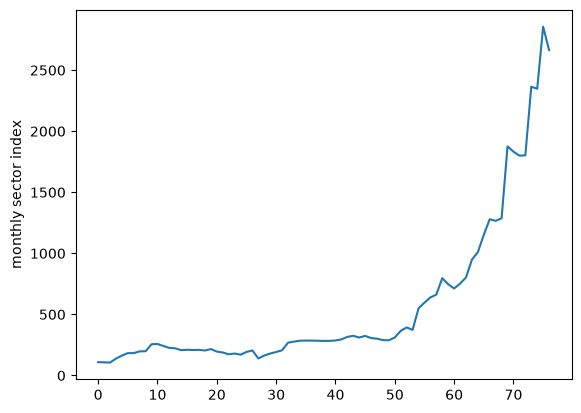

In [19]:
import matplotlib.pyplot as plt
ax=monthly_fin_data['sector_index'].plot()
ax.set_ylabel('monthly sector index')
plt.show()

There is clearly a trend so we will apply differencing.

In [20]:
## Lets check first.
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_index'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(3.239421816841054), 1.0, 11, 65, {'1%': np.float64(-3.5352168748293127), '5%': np.float64(-2.9071540828402367), '10%': np.float64(-2.5911025443786984)}, np.float64(734.6996748488009))
not stationary


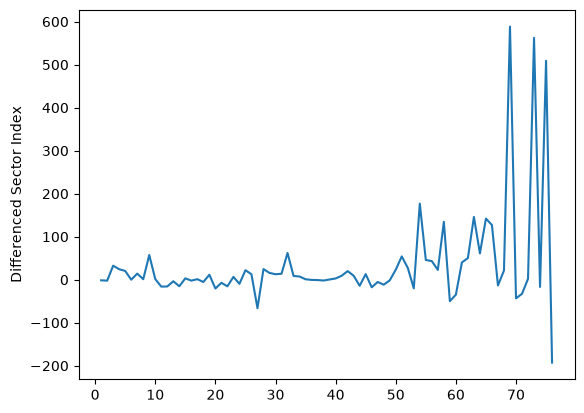

In [21]:
# Difference the data
monthly_fin_data['sector_differenced'] = monthly_fin_data['sector_index'].diff().dropna()

# Plot the differenced data
ax = monthly_fin_data['sector_differenced'].plot()
ax.set_ylabel('Differenced Sector Index')
plt.show()

In [22]:
## Lets check for stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_differenced'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(3.364965410276832), 1.0, 11, 64, {'1%': np.float64(-3.53692771987915), '5%': np.float64(-2.907887369384766), '10%': np.float64(-2.591493291015625)}, np.float64(732.1712992453624))
not stationary


In [23]:
monthly_fin_data

,index,date,sector_index,sector_differenced
0,20,2017-01-31,109.001843,NaN
1,40,2017-02-28,107.626307,-1.375536
2,63,2017-03-31,105.456849,-2.169458
3,102,2017-05-31,138.127184,32.670334
4,122,2017-06-30,162.591431,24.464248
...,...,...,...,...
72,2124,2025-12-31,1802.129757,2.137693
73,2167,2026-02-28,2364.419520,562.289764
74,2190,2026-03-31,2347.696835,-16.722686
75,2210,2026-04-30,2856.819058,509.122223


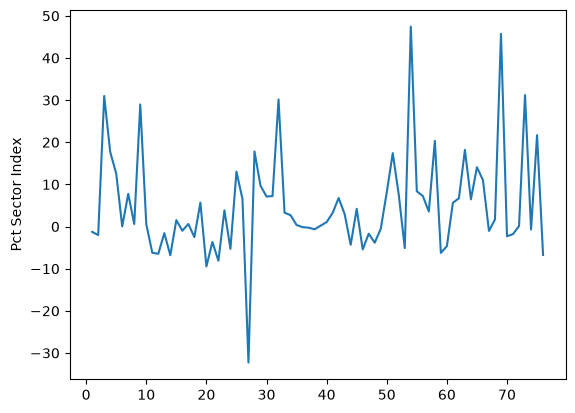

In [24]:
# Difference the data
monthly_fin_data['sector_pct_change'] = monthly_fin_data['sector_index'].pct_change()*100

# Plot the differenced data
ax = monthly_fin_data['sector_pct_change'].plot()
ax.set_ylabel('Pct Sector Index')
plt.show()

In [25]:
monthly_fin_data

,index,date,sector_index,sector_differenced,sector_pct_change
0,20,2017-01-31,109.001843,NaN,NaN
1,40,2017-02-28,107.626307,-1.375536,-1.261938
2,63,2017-03-31,105.456849,-2.169458,-2.015732
3,102,2017-05-31,138.127184,32.670334,30.979813
4,122,2017-06-30,162.591431,24.464248,17.711392
...,...,...,...,...,...
72,2124,2025-12-31,1802.129757,2.137693,0.118761
73,2167,2026-02-28,2364.419520,562.289764,31.201403
74,2190,2026-03-31,2347.696835,-16.722686,-0.707264
75,2210,2026-04-30,2856.819058,509.122223,21.686029


In [26]:
## Lets check for stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_pct_change'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-3.077855004857061), np.float64(0.028236017645485268), 3, 72, {'1%': np.float64(-3.524624466842421), '5%': np.float64(-2.9026070739026064), '10%': np.float64(-2.5886785262345677)}, np.float64(496.0283044748153))
stationary


The sector_percent change is stationary. We will work with it

In [27]:
monthly_fin_data_clean=monthly_fin_data.dropna()

In [28]:
from sklearn.metrics import r2_score

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate2(order):
    train = list(monthly_fin_data_clean['sector_pct_change'])[:-10]
    test = list(monthly_fin_data_clean['sector_pct_change'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(monthly_fin_data_clean['sector_pct_change']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [29]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate2(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

results



,orders,scores
0,1,-0.273740
1,2,-0.271669
2,3,-0.238082
3,4,-0.158674
4,5,-0.199748
5,6,-0.180123
6,7,-0.174197
7,8,-0.273421
8,9,-0.279946
9,10,-0.304662


In [30]:
# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
3,4,-0.158674


In [31]:
train = list(monthly_fin_data_clean['sector_pct_change'])[:-10]
test = list(monthly_fin_data_clean['sector_pct_change'])[-10:]

coefficients, sigma = yule_walker(train, order = 4)

# Make a list of differenced values
val_list = list(train)

# Reverse the list to corresponds with the order of coefs
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each day to predict
for i in range(n_steps):
    # Compute the new value
    new_val = 0
    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverse to have the order of time
val_list.reverse()
new_val_list= val_list

# Plot the newly obtained list
test_validation = pd.DataFrame({
    'original': list(monthly_fin_data_clean['sector_pct_change']),
    'test_pred': new_val_list 
})

print('Test R2: ', r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])) 


Test R2:  -0.15867358314169366


In [32]:
test_validation

,original,test_pred
0,-1.261938,-1.261938
1,-2.015732,-2.015732
2,30.979813,30.979813
3,17.711392,17.711392
4,12.577373,12.577373
...,...,...
71,0.118761,0.887017
72,31.201403,0.860751
73,-0.707264,0.550154
74,21.686029,0.311540


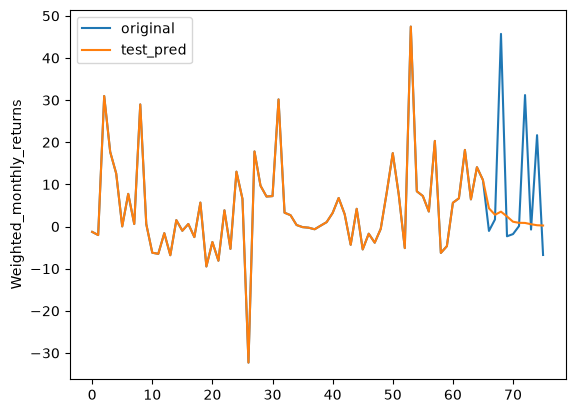

In [33]:
# Plot the newly obtained list
plt.plot(test_validation)
plt.legend(test_validation.columns)
plt.ylabel('Weighted_monthly_returns')
plt.show()

You can see very poor performance. Lets check order from 31 to 60.

In [34]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(31, 61):
    orders.append(order)
    r2scores.append(evaluate2(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

results


,orders,scores
0,31,-9.416911e-01
1,32,-9.306142e-01
2,33,-9.900393e-01
3,34,-1.006070e+00
4,35,-1.325395e+00
5,36,-1.311617e+00
6,37,-1.809058e+00
7,38,-1.783850e+00
8,39,-1.698182e+00
9,40,-1.923613e+00


Its obvious that only autoregression failed.

Before we move to Moving Average, let us try checking the autocorrelation function to select the coefficients that have any significance and block out the rest

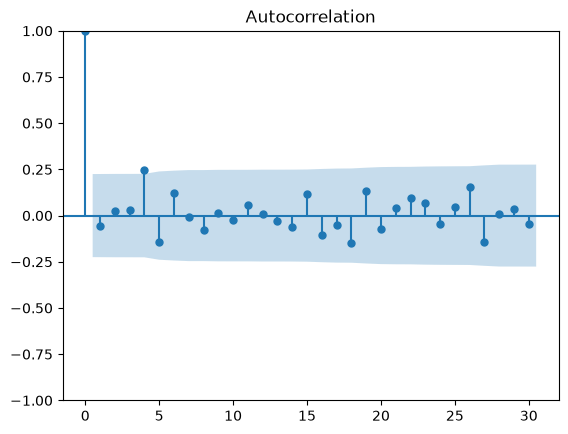

In [35]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(monthly_fin_data_clean['sector_pct_change'], lags=30) ## acf is short for autocorrelation function
plt.show()

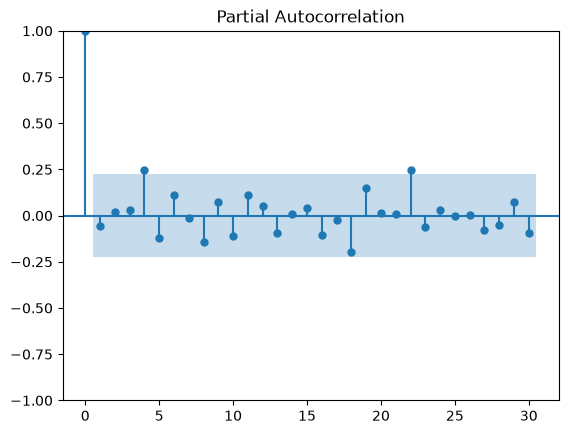

In [36]:
## partial autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(monthly_fin_data_clean['sector_pct_change'], lags = 30)
plt.show()

We can see that lag 4 and lag 22 have an impact. We will use just these two cofficients to carryout predictions.

NOTE: We are just testing.

In [37]:
# Estimate Yule-Walker AR coefficients with order 20
from statsmodels.regression.linear_model import yule_walker

coefficients, sigma = yule_walker(monthly_fin_data_clean['sector_pct_change'], order = 25)

print('coefficients: ', -coefficients)
print('sigma: ', sigma)

coefficients:  [-1.59242496e-01  6.77043709e-02  3.96194712e-02 -4.79433103e-01
  3.20721928e-01 -3.14989207e-01  4.85835585e-02  3.20174486e-01
 -3.01409110e-01  3.21497710e-01 -1.52286177e-01 -2.10362409e-01
  3.12412270e-01 -3.34498248e-01  9.93983006e-02  1.87524451e-01
 -1.22522544e-01  4.75074953e-01 -3.02852302e-01  3.54212895e-02
  2.16864770e-02 -4.09120628e-01  1.74821434e-01 -9.31472076e-02
 -1.31927424e-04]
sigma:  9.282595338159924


In [38]:
len(coefficients)

25

In [40]:
coeff_=[coefficients[3],coefficients[21]]
coeff_

[np.float64(0.4794331025196199), np.float64(0.40912062800547744)]

In [41]:
train = list(monthly_fin_data_clean['sector_pct_change'])[:-10]
test = list(monthly_fin_data_clean['sector_pct_change'])[-10:]

# Make a list of differenced values
val_list = list(train)

# Reverse the list to corresponds with the order of coefs
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each day to predict
for i in range(n_steps):
    # Compute the new value
    new_val = 0
    for j in range(len(coeff_)):
        new_val += coeff_[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverse to have the order of time
val_list.reverse()
new_val_list= val_list

# Plot the newly obtained list
test_validation = pd.DataFrame({
    'original': list(monthly_fin_data_clean['sector_pct_change']),
    'test_pred': new_val_list 
})

print('Test R2: ', r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])) 


Test R2:  -0.010735228034251865


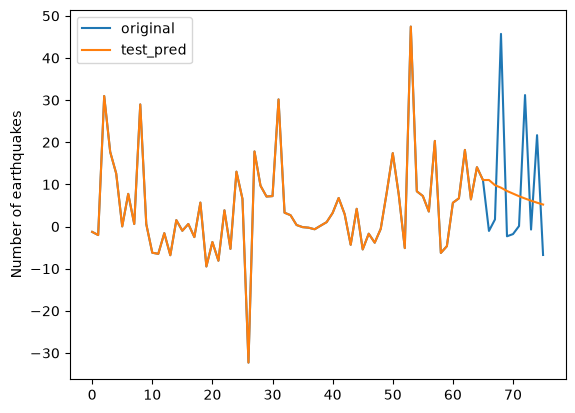

In [42]:
# Plot the newly obtained list
plt.plot(test_validation)
plt.legend(test_validation.columns)
plt.ylabel('Number of earthquakes')
plt.show()

Test Failed. This was really poor. This is because we cant just throw away all other coefficients because they all depend on each other. 

We will try the approach below.

In [43]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(
    monthly_fin_data_clean['sector_pct_change'],
    lags=[4, 22],
    trend='c'
)

results = model.fit()

print(results.summary())

ValueError: operands could not be broadcast together with shapes (54,) (55,) 

In [44]:
y = monthly_fin_data_clean['sector_pct_change']

print(len(y))
print(y.shape)
print(y.isna().sum())
print(y.index)

76
(76,)
0
RangeIndex(start=1, stop=77, step=1)


In [45]:
y

1     -1.261938
2     -2.015732
3     30.979813
4     17.711392
5     12.577373
        ...    
72     0.118761
73    31.201403
74    -0.707264
75    21.686029
76    -6.742996
Name: sector_pct_change, Length: 76, dtype: float64

In [46]:
y = monthly_fin_data_clean['sector_pct_change'].dropna().reset_index(drop=True)

model = AutoReg(
    y,
    lags=[4, 22],
    trend='c'
)

results = model.fit()

print(results.summary())

                            AutoReg Model Results                             
Dep. Variable:      sector_pct_change   No. Observations:                   76
Model:             Restr. AutoReg(22)   Log Likelihood                -210.573
Method:               Conditional MLE   S.D. of innovations             11.948
Date:                Fri, 21 Aug 2026   AIC                            429.145
Time:                        13:47:02   BIC                            437.101
Sample:                            22   HQIC                           432.213
                                   76                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     3.5884      1.863      1.926      0.054      -0.063       7.239
sector_pct_change.L4      0.3196      0.136      2.351      0.019       0.053       0.586
sector_p

We have seen that in this data only lag 4 has any significance so we will run and test with this lag 4. NOTE lag 22 is a bit too much for this sample size.

In [51]:
y = monthly_fin_data_clean['sector_pct_change'].dropna().reset_index(drop=True)

train = y.iloc[:-10]
test = y.iloc[-10:]

model_4 = AutoReg(
    train,
    lags=[4],
    trend='c'
)

results_4 = model_4.fit()


In [52]:
forecast_4 = results_4.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print(forecast_4)

66    6.377923
67    4.383010
68    5.680377
69    5.161692
70    4.369700
71    4.030392
72    4.251057
73    4.162835
74    4.028128
75    3.970417
dtype: float64


In [53]:
print(test)

66    -1.041722
67     1.685468
68    45.715396
69    -2.305680
70    -1.785718
71     0.118761
72    31.201403
73    -0.707264
74    21.686029
75    -6.742996
Name: sector_pct_change, dtype: float64


With the naked eye we can see that the forcast is far off.

In [50]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_4 = np.sqrt(
    mean_squared_error(test, forecast_4)
)

print("RMSE:", rmse_4)

RMSE: 17.177601759678275


Lets take this approach with te full data

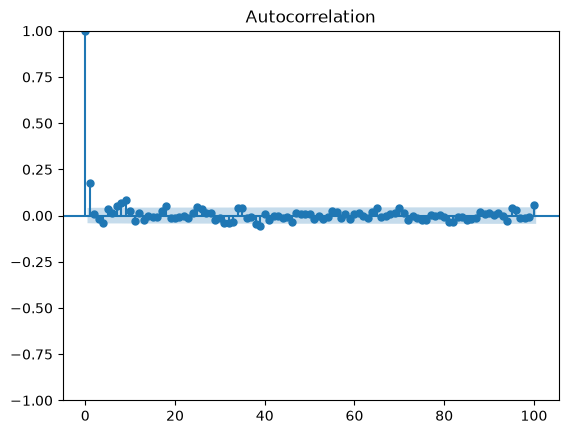

In [54]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(fin_data['weighted_sector_returns'], lags=100) ## acf is short for autocorrelation function
plt.show()

In [ ]:
y = fin_data['weighted_sector_returns'].dropna().reset_index(drop=True)

train = y.iloc[:-10]
test = y.iloc[-10:]

model_100L = AutoReg(
    train,
    lags=range(1,101),
    trend='c'
)

results_100L = model_100L.fit()
print(results_100L.summary())

                               AutoReg Model Results                               
Dep. Variable:     weighted_sector_returns   No. Observations:                 2253
Model:                        AutoReg(100)   Log Likelihood               -3997.653
Method:                    Conditional MLE   S.D. of innovations              1.549
Date:                     Fri, 21 Aug 2026   AIC                           8199.306
Time:                             14:15:09   BIC                           8778.117
Sample:                                100   HQIC                          8411.041
                                      2253                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.1135      0.042      2.678      0.007       0.030       0.197
weighted_sector_returns.L1       0.16

I used 0.025 level of significance. Therefore Lags[1,9,18,34,100] have significance to this model.

In [58]:
model_sig = AutoReg(
    train,
    lags=[1,9,18,34,100],
    trend='c'
)

result_sig=model_sig.fit()
print(result_sig.summary())

                               AutoReg Model Results                               
Dep. Variable:     weighted_sector_returns   No. Observations:                 2253
Model:                 Restr. AutoReg(100)   Log Likelihood               -4047.790
Method:                    Conditional MLE   S.D. of innovations              1.586
Date:                     Fri, 21 Aug 2026   AIC                           8109.579
Time:                             14:27:46   BIC                           8149.302
Sample:                                100   HQIC                          8124.110
                                      2253                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.0907      0.035      2.594      0.009       0.022       0.159
weighted_sector_returns.L1       0.16

In [59]:
forecast_sig = result_sig.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print(forecast_sig)

2253    0.626803
2254    0.253863
2255    0.049607
2256    0.275212
2257    0.295200
2258   -0.172136
2259   -0.088192
2260    0.009354
2261    0.452014
2262    0.274027
dtype: float64


Lets compare with 100L

In [60]:
forecast_100L = results_100L.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

print(forecast_100L)

2253    0.397329
2254   -0.812177
2255   -0.077174
2256    0.013959
2257    0.292111
2258   -0.078530
2259    0.084992
2260    0.556375
2261    0.711805
2262    0.480949
dtype: float64


In [61]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

rmse_sig = np.sqrt(
    mean_squared_error(test, forecast_sig)
)
rmse_100L = np.sqrt(
    mean_squared_error(test, forecast_100L)
)

print("RMSE_SIG:", rmse_sig)
print("RMSE_100L:", rmse_100L)
print("r2_score SIG: ", r2_score(test,forecast_sig))
print("r2_score 100L: ", r2_score(test,forecast_100L))


RMSE_SIG: 0.9555737674953801
RMSE_100L: 0.9117009510507055
r2_score SIG:  -0.035941866881340934
r2_score 100L:  0.05699984760552956


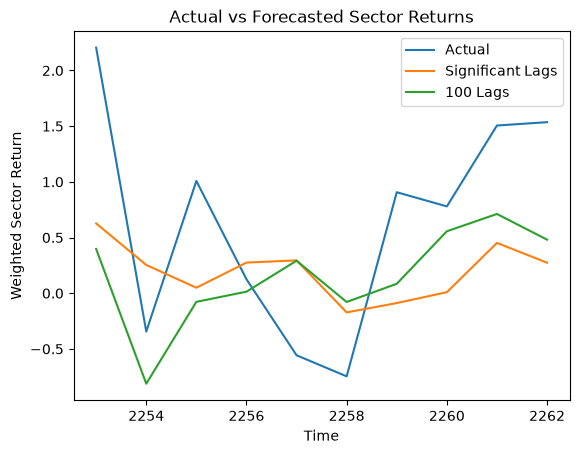

In [63]:
import matplotlib.pyplot as plt

plt.plot(test, label="Actual")
plt.plot(forecast_sig, label="Significant Lags")
plt.plot(forecast_100L, label="100 Lags")

plt.ylabel("Weighted Sector Return")
plt.legend()
plt.xlabel("Time")
plt.title("Actual vs Forecasted Sector Returns")

plt.show()

THis is still very poor. We have to move on to Moving average

### Moving Average

In [64]:
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893
